In [20]:
pip install tensorflow

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 23.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 42.8 MB/s eta 0:00:0000:01:00:01
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/6f/12/d5c79ee252793ffe845d58a913197bfa02ae9a0b5c9bc3dc4b58d477b9e7/flatbuffers-23.5.26-py2.py3-none-any.whl (26 kB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/01/e4/dc0a1dcc4e74e08d7abedab278c795eef54a224363bb18f5692f416d834f/absl_py-2.0.0-py3-none-any.whl (130 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 27.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 41.7 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━

In [63]:
import numpy as np 
import pandas as pd 
import os
import time
import seaborn as sns 
import matplotlib.pyplot as plt
# %matplotlib inline
# plt.style.use('ggplot')
import lightgbm as lgb
import xgboost as xgb
# import plotly.offline as py
# py.init_notebook_mode(connected=True)
import warnings
warnings.filterwarnings("ignore")
# import time
# import datetime
# print(plt.style.available)
# plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 1})
sns.set(font_scale=2)
pd.set_option('display.max_columns', 500)


In [64]:
%time train=pd.read_csv('./train.csv')
# train = reduce_mem_usage(train)
%time test=pd.read_csv('./test.csv')
# test = reduce_mem_usage(test)

CPU times: user 1min 14s, sys: 12.2 s, total: 1min 26s
Wall time: 1min 26s
CPU times: user 1min 2s, sys: 8.29 s, total: 1min 10s
Wall time: 1min 10s


In [65]:
#合并训练集和测试集，便于进行统一数据预处理
X = pd.concat([train,test])
# y = train[['HasDetections']]

In [4]:
X.head()

,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,AVProductStatesIdentifier,AVProductsInstalled,AVProductsEnabled,HasTpm,CountryIdentifier,CityIdentifier,OrganizationIdentifier,GeoNameIdentifier,LocaleEnglishNameIdentifier,Platform,Processor,OsVer,OsBuild,OsSuite,OsPlatformSubRelease,OsBuildLab,SkuEdition,IsProtected,AutoSampleOptIn,PuaMode,SMode,IeVerIdentifier,SmartScreen,Firewall,UacLuaenable,Census_MDC2FormFactor,Census_DeviceFamily,Census_OEMNameIdentifier,Census_OEMModelIdentifier,Census_ProcessorCoreCount,Census_ProcessorManufacturerIdentifier,Census_ProcessorModelIdentifier,Census_ProcessorClass,Census_PrimaryDiskTotalCapacity,Census_PrimaryDiskTypeName,Census_SystemVolumeTotalCapacity,Census_HasOpticalDiskDrive,Census_TotalPhysicalRAM,Census_ChassisTypeName,Census_InternalPrimaryDiagonalDisplaySizeInInches,Census_InternalPrimaryDisplayResolutionHorizontal,Census_InternalPrimaryDisplayResolutionVertical,Census_PowerPlatformRoleName,Census_InternalBatteryType,Census_InternalBatteryNumberOfCharges,Census_OSVersion,Census_OSArchitecture,Census_OSBranch,Census_OSBuildNumber,Census_OSBuildRevision,Census_OSEdition,Census_OSSkuName,Census_OSInstallTypeName,Census_OSInstallLanguageIdentifier,Census_OSUILocaleIdentifier,Census_OSWUAutoUpdateOptionsName,Census_IsPortableOperatingSystem,Census_GenuineStateName,Census_ActivationChannel,Census_IsFlightingInternal,Census_IsFlightsDisabled,Census_FlightRing,Census_ThresholdOptIn,Census_FirmwareManufacturerIdentifier,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,0000028988387b115f69f31a3bf04f09,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1735.0,0,7.0,0,NaN,53447.0,1.0,1.0,1,29,128035.0,18.0,35.0,171,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.0,0,NaN,0.0,137.0,NaN,1.0,1.0,Desktop,Windows.Desktop,2668.0,9124.0,4.0,5.0,2341.0,NaN,476940.0,HDD,299451.0,0,4096.0,Desktop,18.9,1440.0,900.0,Desktop,NaN,4.294967e+09,10.0.17134.165,amd64,rs4_release,17134,165,Professional,PROFESSIONAL,UUPUpgrade,26.0,119,UNKNOWN,0,IS_GENUINE,Retail,NaN,0.0,Retail,NaN,628.0,36144.0,0,NaN,0.0,0,0,0.0,0.0,10.0,0.0
1,000007535c3f730efa9ea0b7ef1bd645,win8defender,1.1.14600.4,4.13.17134.1,1.263.48.0,0,7.0,0,NaN,53447.0,1.0,1.0,1,93,1482.0,18.0,119.0,64,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.0,0,NaN,0.0,137.0,NaN,1.0,1.0,Notebook,Windows.Desktop,2668.0,91656.0,4.0,5.0,2405.0,NaN,476940.0,HDD,102385.0,0,4096.0,Notebook,13.9,1366.0,768.0,Mobile,NaN,1.000000e+00,10.0.17134.1,amd64,rs4_release,17134,1,Professional,PROFESSIONAL,IBSClean,8.0,31,UNKNOWN,0,OFFLINE,Retail,NaN,0.0,NOT_SET,NaN,628.0,57858.0,0,NaN,0.0,0,0,0.0,0.0,8.0,0.0
2,000007905a28d863f6d0d597892cd692,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1341.0,0,7.0,0,NaN,53447.0,1.0,1.0,1,86,153579.0,18.0,64.0,49,windows10,x64,10.0.0.0,17134,768,rs4,17134.1.amd64fre.rs4_release.180410-1804,Home,1.0,0,NaN,0.0,137.0,RequireAdmin,1.0,1.0,Desktop,Windows.Desktop,4909.0,317701.0,4.0,5.0,1972.0,NaN,114473.0,SSD,113907.0,0,4096.0,Desktop,21.5,1920.0,1080.0,Desktop,NaN,4.294967e+09,10.0.17134.165,amd64,rs4_release,17134,165,Core,CORE,UUPUpgrade,7.0,30,FullAuto,0,IS_GENUINE,OEM:NONSLP,NaN,0.0,Retail,NaN,142.0,52682.0,0,NaN,0.0,0,0,0.0,0.0,3.0,0.0
3,00000b11598a75ea8ba1beea8459149f,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1527.0,0,7.0,0,NaN,53447.0,1.0,1.0,1,88,20710.0,NaN,117.0,115,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.0,0,NaN,0.0,137.0,ExistsNotSet,1.0,1.0,Desktop,Windows.Desktop,1443.0,275890.0,4.0,5.0,2273.0,NaN,238475.0,UNKNOWN,227116.0,0,4096.0,MiniTower,18.5,1366.0,768.0,Desktop,NaN,4.294967e+09,10.0.17134.228,amd64,rs4_release,17134,228,Professional,PR

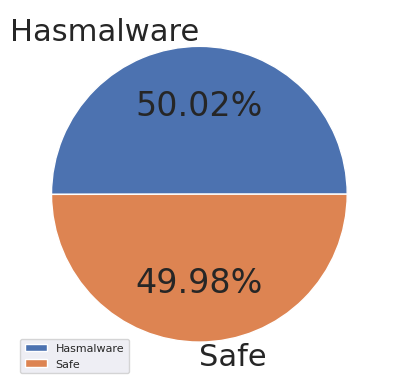

In [9]:
#查看预测变量的分布情况
Hasdetection_values=X['HasDetections'].value_counts().values

plt.pie(Hasdetection_values.tolist(), labels=['Hasmalware','Safe'], autopct='%.2f%%')
plt.legend(loc='lower left', prop={'size': 8})
plt.show()

In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16774736 entries, 0 to 7853252
Data columns (total 83 columns):
 #   Column                                             Dtype  
---  ------                                             -----  
 0   MachineIdentifier                                  object 
 1   ProductName                                        object 
 2   EngineVersion                                      object 
 3   AppVersion                                         object 
 4   AvSigVersion                                       object 
 5   IsBeta                                             int64  
 6   RtpStateBitfield                                   float64
 7   IsSxsPassiveMode                                   int64  
 8   DefaultBrowsersIdentifier                          float64
 9   AVProductStatesIdentifier                          float64
 10  AVProductsInstalled                                float64
 11  AVProductsEnabled                                  flo

In [4]:
#意义为NA的标签
null_num_var = ['RtpStateBitfield','IsSxsPassiveMode','AVProductsInstalled','AVProductsEnabled','IeVerIdentifier','Census_OEMNameIdentifier',
                'Census_OEMModelIdentifier', 'Census_ProcessorManufacturerIdentifier', 'Census_ProcessorModelIdentifier', 'Census_InternalBatteryType', 
                'Census_InternalBatteryNumberOfCharges', 'Census_OSInstallLanguageIdentifier','Census_OSUILocaleIdentifier','Census_IsFlightingInternal',
               'Census_ThresholdOptIn','Census_FirmwareManufacturerIdentifier','Census_FirmwareVersionIdentifier','Census_IsWIMBootEnabled','Wdft_RegionIdentifier']
#几乎所有数据都为分类数据，暂时排除意义NA标签
categorical = []
for i in X.columns:
    if i not in null_num_var:
        categorical.append(i)
        print(i)

MachineIdentifier
ProductName
EngineVersion
AppVersion
AvSigVersion
IsBeta
DefaultBrowsersIdentifier
AVProductStatesIdentifier
HasTpm
CountryIdentifier
CityIdentifier
OrganizationIdentifier
GeoNameIdentifier
LocaleEnglishNameIdentifier
Platform
Processor
OsVer
OsBuild
OsSuite
OsPlatformSubRelease
OsBuildLab
SkuEdition
IsProtected
AutoSampleOptIn
PuaMode
SMode
SmartScreen
Firewall
UacLuaenable
Census_MDC2FormFactor
Census_DeviceFamily
Census_ProcessorCoreCount
Census_ProcessorClass
Census_PrimaryDiskTotalCapacity
Census_PrimaryDiskTypeName
Census_SystemVolumeTotalCapacity
Census_HasOpticalDiskDrive
Census_TotalPhysicalRAM
Census_ChassisTypeName
Census_InternalPrimaryDiagonalDisplaySizeInInches
Census_InternalPrimaryDisplayResolutionHorizontal
Census_InternalPrimaryDisplayResolutionVertical
Census_PowerPlatformRoleName
Census_OSVersion
Census_OSArchitecture
Census_OSBranch
Census_OSBuildNumber
Census_OSBuildRevision
Census_OSEdition
Census_OSSkuName
Census_OSInstallTypeName
Census_OSWUAu

In [66]:
#特征工程
#去掉太多单一值的分类数据
num_col = X.columns
overfit_num = []
for i in num_col:
    counts = X[i].value_counts()
    zeros = counts.iloc[0]
    if zeros / len(X) * 100 > 95:
        overfit_num.append(i)

overfit_num = list(overfit_num)
X.drop(overfit_num, axis=1,inplace=True)
print("Features with >95% of the same value: ",overfit_num)

Features with >95% of the same value:  ['ProductName', 'IsBeta', 'RtpStateBitfield', 'IsSxsPassiveMode', 'AVProductsEnabled', 'HasTpm', 'Platform', 'OsVer', 'AutoSampleOptIn', 'Firewall', 'UacLuaenable', 'Census_DeviceFamily', 'Census_IsPortableOperatingSystem', 'Census_IsFlightsDisabled', 'Census_IsVirtualDevice', 'Census_IsPenCapable']


<AxesSubplot:title={'center':'Number of missing rows'}, xlabel='features', ylabel='sum'>

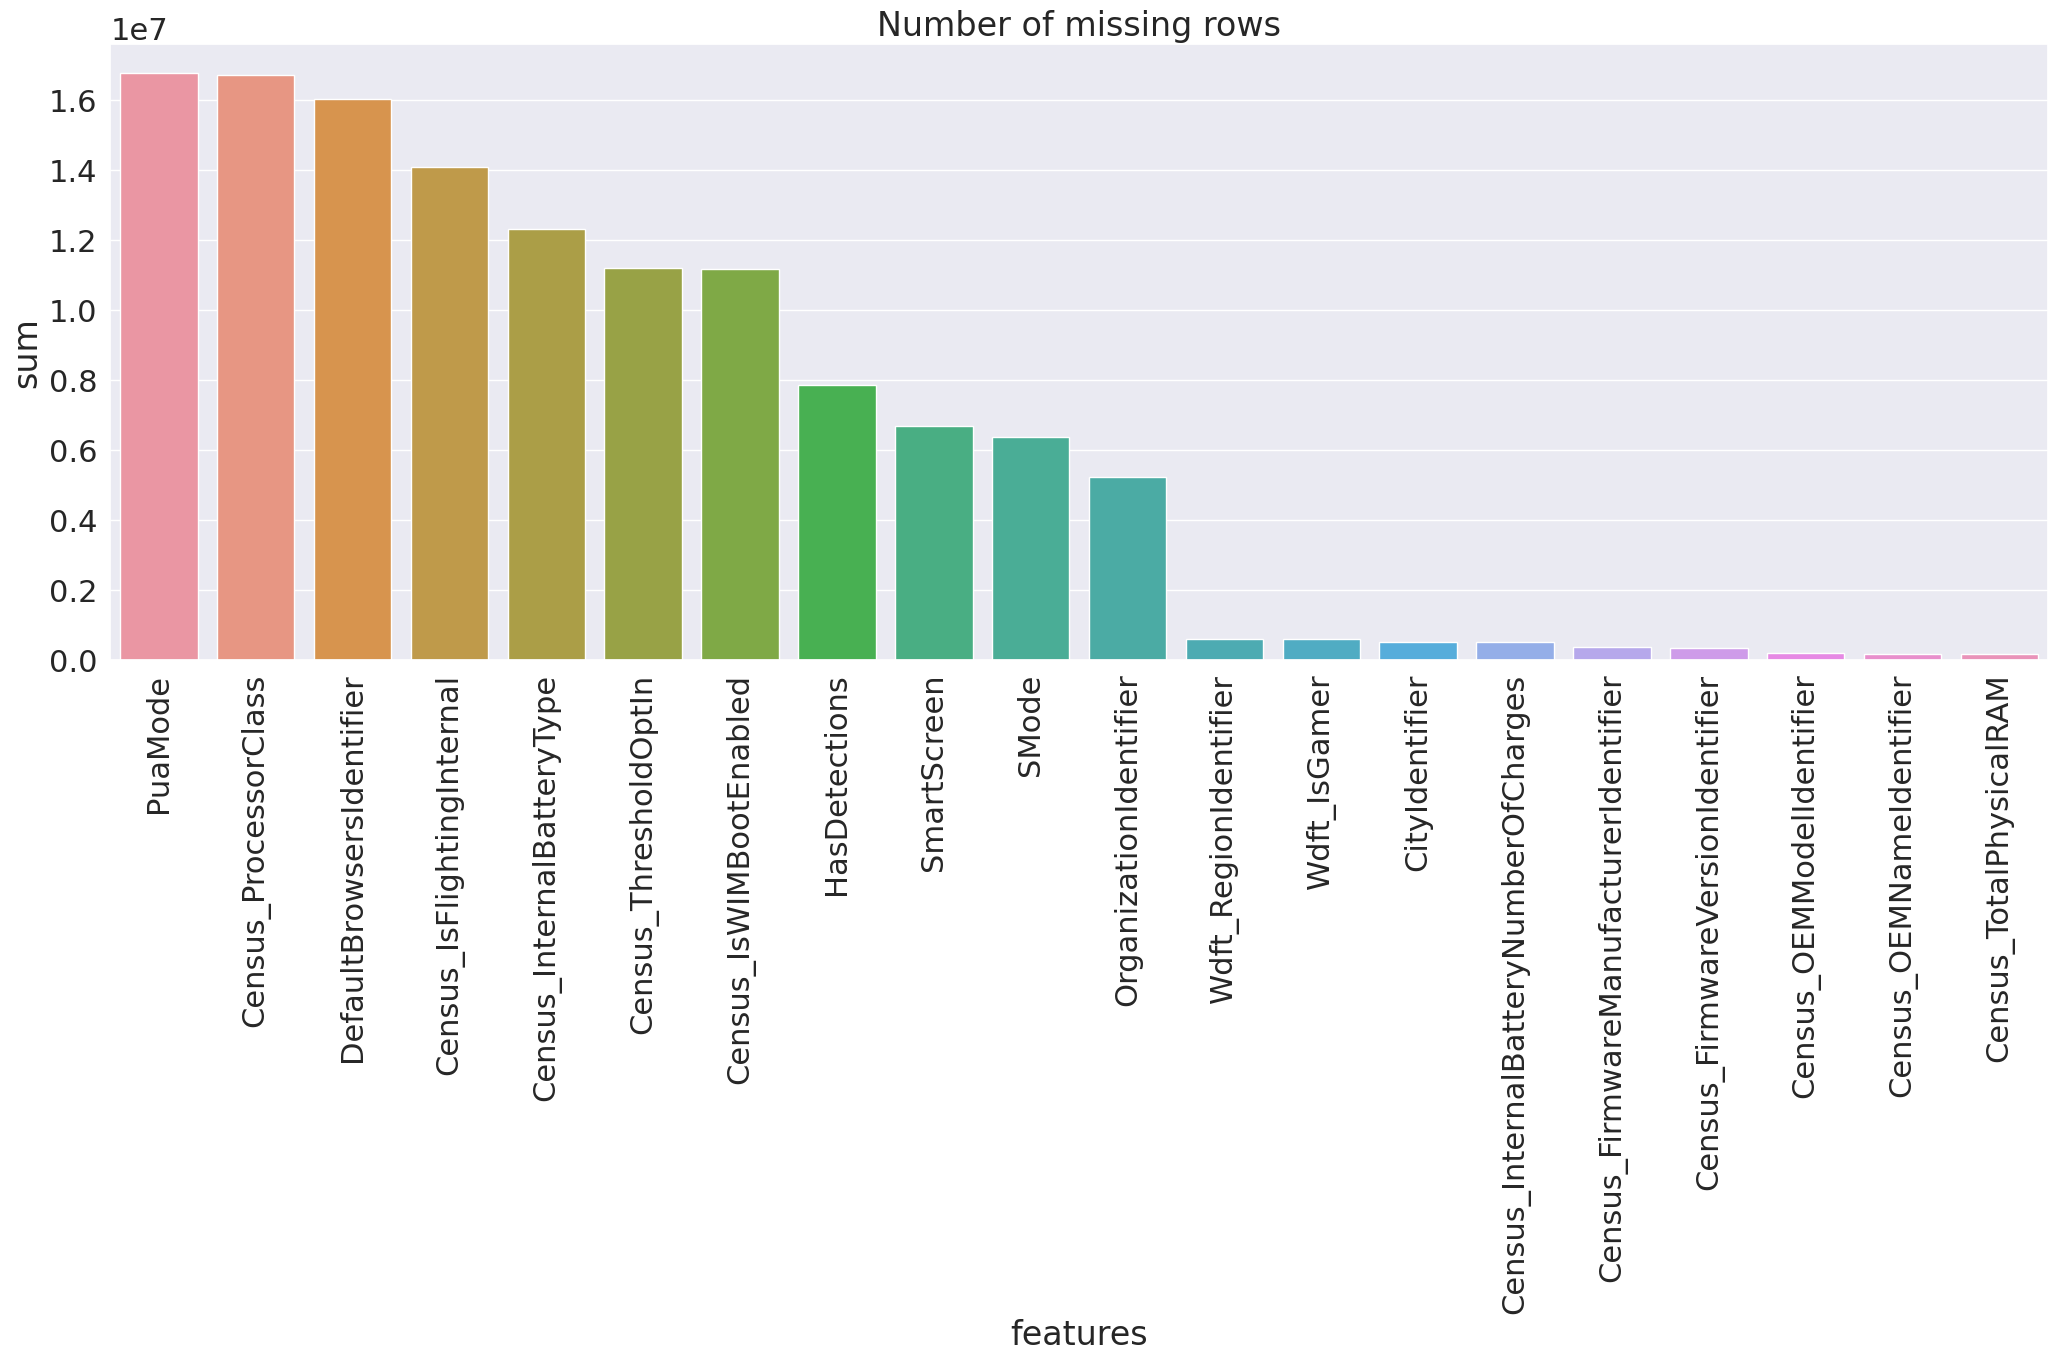

In [151]:
#去掉有太多缺失值的特征
plt.figure(figsize=(25,8))
plt.title('Number of missing rows')
missing_count = pd.DataFrame(X.isnull().sum(), columns=['sum']).sort_values(by=['sum'],ascending=False).head(20).reset_index()
missing_count.columns = ['features','sum']
plt.xticks(rotation=90)
sns.barplot(x='features',y='sum', data = missing_count)

In [67]:
X.drop(['PuaMode','Census_ProcessorClass'],axis=1, inplace=True)

In [68]:
#可能需要对数据进行标准化处理
#处理缺失值
#把identifier的特征缺失值替换成0
id_col=[]
for i in X.columns:
    if i[-10:]=='Identifier':
        id_col.append(i)
        X.replace({i: {np.nan: 0}}, inplace=True)
print(id_col)

['MachineIdentifier', 'DefaultBrowsersIdentifier', 'AVProductStatesIdentifier', 'CountryIdentifier', 'CityIdentifier', 'OrganizationIdentifier', 'GeoNameIdentifier', 'LocaleEnglishNameIdentifier', 'IeVerIdentifier', 'Census_OEMNameIdentifier', 'Census_OEMModelIdentifier', 'Census_ProcessorManufacturerIdentifier', 'Census_ProcessorModelIdentifier', 'Census_OSInstallLanguageIdentifier', 'Census_OSUILocaleIdentifier', 'Census_FirmwareManufacturerIdentifier', 'Census_FirmwareVersionIdentifier', 'Wdft_RegionIdentifier']


In [23]:
#填充缺失值
#查看缺失值
pd.DataFrame(X.isnull().sum(), columns=['sum']).sort_values(by=['sum'],ascending=False).head(15)

,sum
DefaultBrowsersIdentifier,16034179
Census_IsFlightingInternal,14082721
Census_InternalBatteryType,12318273
Census_ThresholdOptIn,11196840
SMode,6369031
OrganizationIdentifier,5233647
Wdft_RegionIdentifier,606308
CityIdentifier,517371
Census_FirmwareManufacturerIdentifier,381891
Census_FirmwareVersionIdentifier,337757


In [69]:
#填充缺失值
#自主选择特征
#Identifier填充缺失值似乎没什么意义,暂时填充别的特征
# cols=['Census_InternalBatteryNumberOfCharges','Wdft_IsGamer','SmartScreen','Census_IsWIMBootEnabled']
cols=X.columns
X[cols] = X[cols].transform(lambda x: x.fillna(x.mode()[0]))

In [ ]:
#特征编码
X.info()

In [38]:
col=[]
for i in X.columns:
    if X[i].dtype!='object':
        col.append(i)

In [18]:
#把不同类型的数据都转换为分类数据
# for i in X.columns:
#     X[i] = X[i].astype('category')
    # plot_categorical_feature('', True)
# X.info()

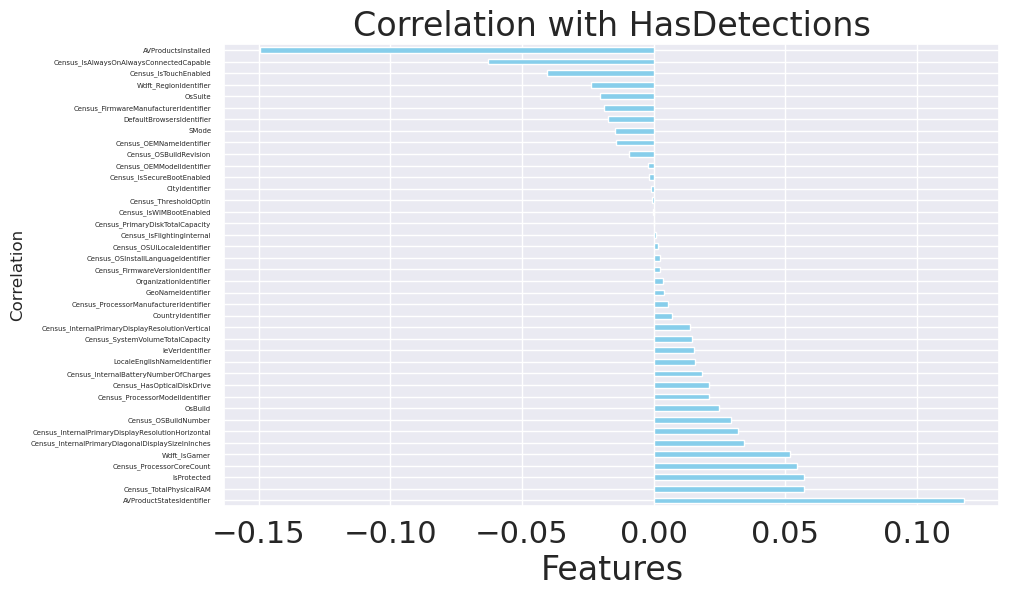

In [39]:
#特征对预测结果影响排序(特征重要性排序）
correlation = X[col].corr()
correlation_has_detections = correlation['HasDetections'].sort_values(ascending=False)

# Creating a bar chart
plt.subplots(figsize=(10, 6))
correlation_has_detections.drop(['HasDetections'],inplace=True)
bar_plot = correlation_has_detections.plot(kind='barh', color='skyblue')
plt.title('Correlation with HasDetections')
plt.xlabel('Features')
plt.ylabel('Correlation',fontsize=12)
bar_plot.tick_params(axis='y', labelsize=5)


# cbar = plt.colorbar(bar_plot, orientation='vertical', pad=0.1)
# cbar.set_ticks([round(i, 2) for i in correlation_has_detections])
# cbar.set_label('Correlation', rotation=270, labelpad=15, fontsize=14)

plt.show()

In [40]:
#模型优化尝试特征工程，删除影响低的特征
correlation_has_detections.drop(['Wdft_IsGamer','Census_ProcessorCoreCount','IsProtected','Census_TotalPhysicalRAM','AVProductStatesIdentifier'],inplace=True)

In [43]:
for i in X.columns:
    if i == 'DefaultBrowsersIdentifier' or  'AVProductsInstalled':
        continue
    if i in correlation_has_detections:
        X.drop([i],inplace=True)
    
    

In [8]:
# print(X)

In [14]:
# 计算协方差矩阵
# 绘制热图函数
def corr_heatmap(cols):
    # temp = pd.concat([X,y])
    # correlations = temp[cols+['HasDetections']].corr()
    correlations = X[cols+['HasDetections']].corr()
    # Create color map ranging between two colors
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.heatmap(correlations, cmap=cmap, vmax=1.0, center=0, fmt='.2f',
                square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .75})
    plt.show()

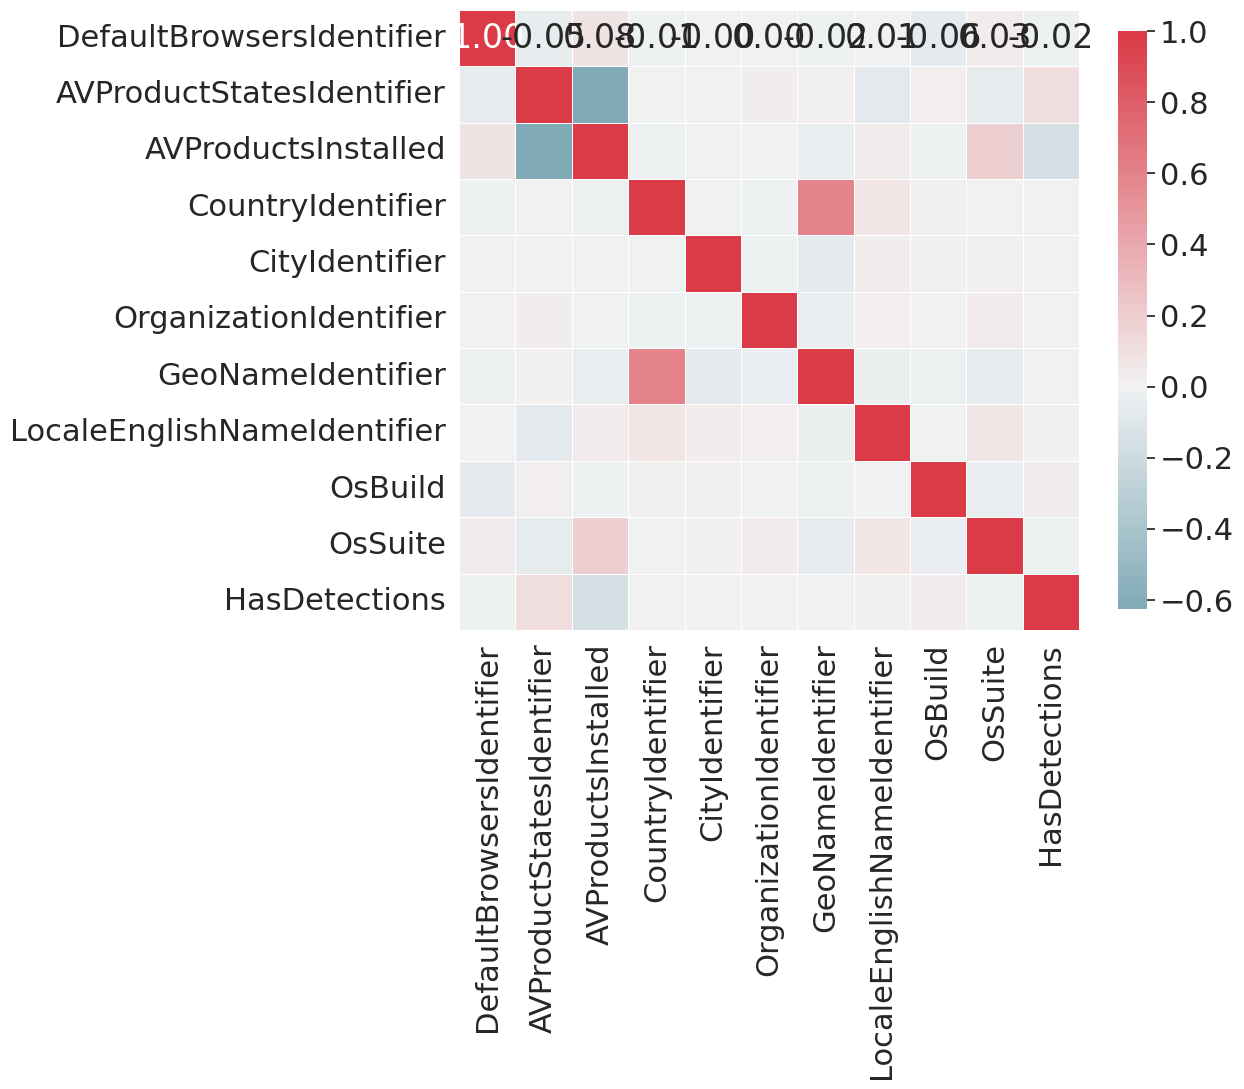

In [15]:
#对X所有，包含意义NA的数值特征进行关联分析
corr_heatmap(col[:10])

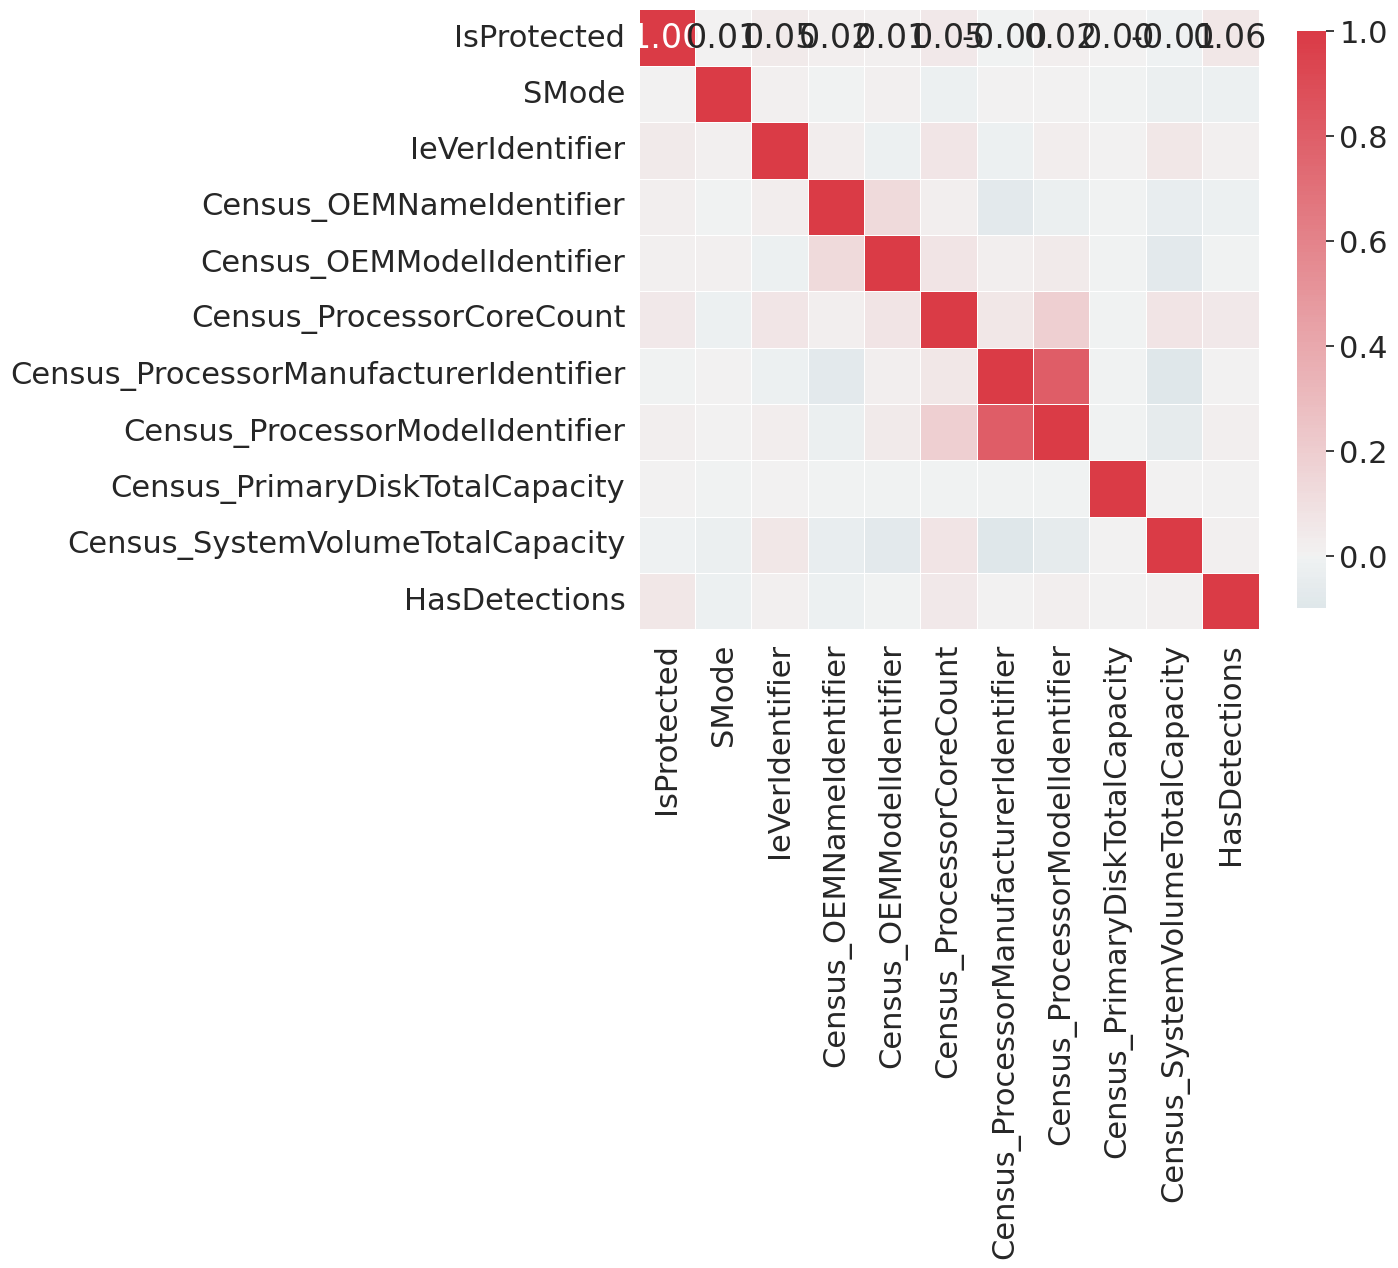

In [16]:
corr_heatmap(col[10:20])

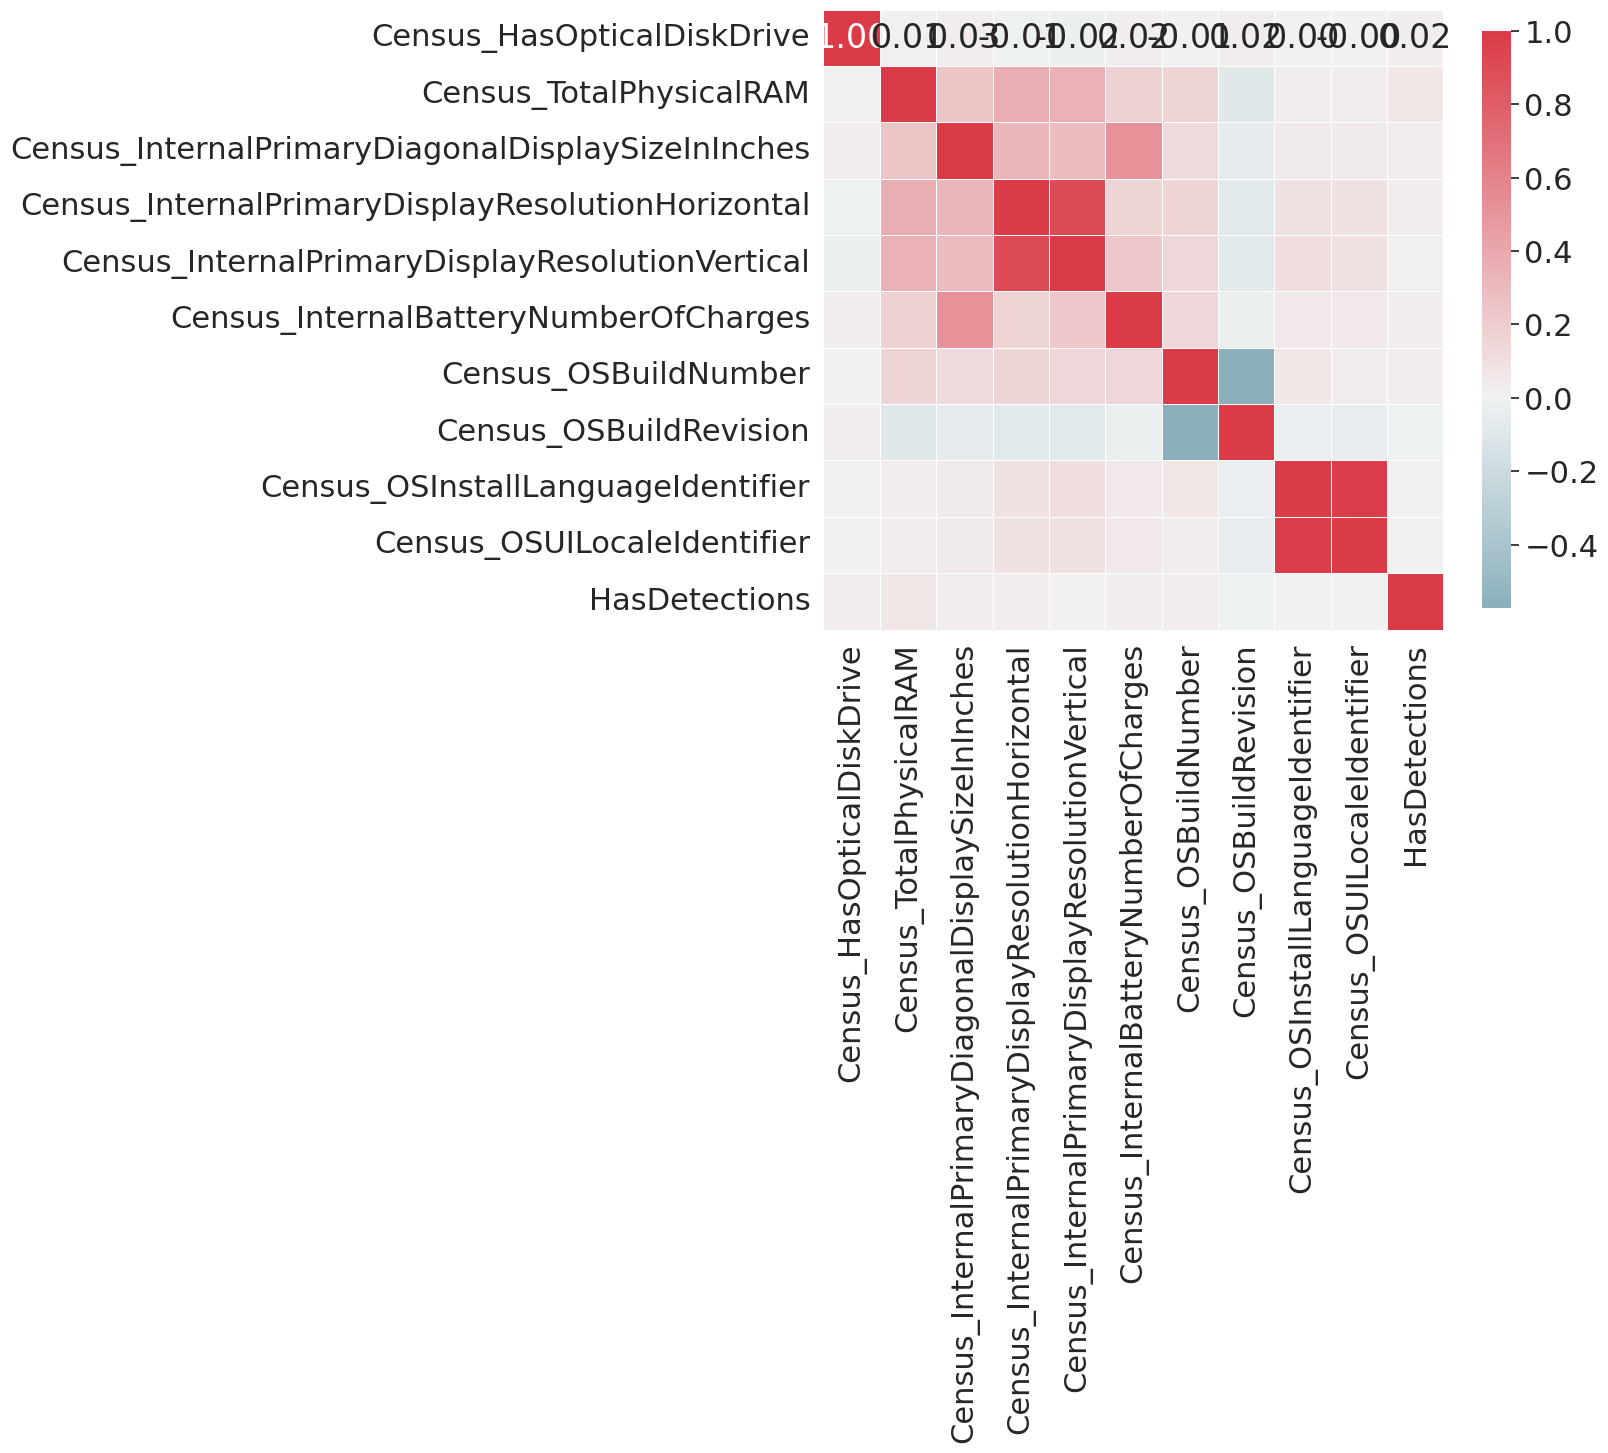

In [17]:
corr_heatmap(col[20:30])

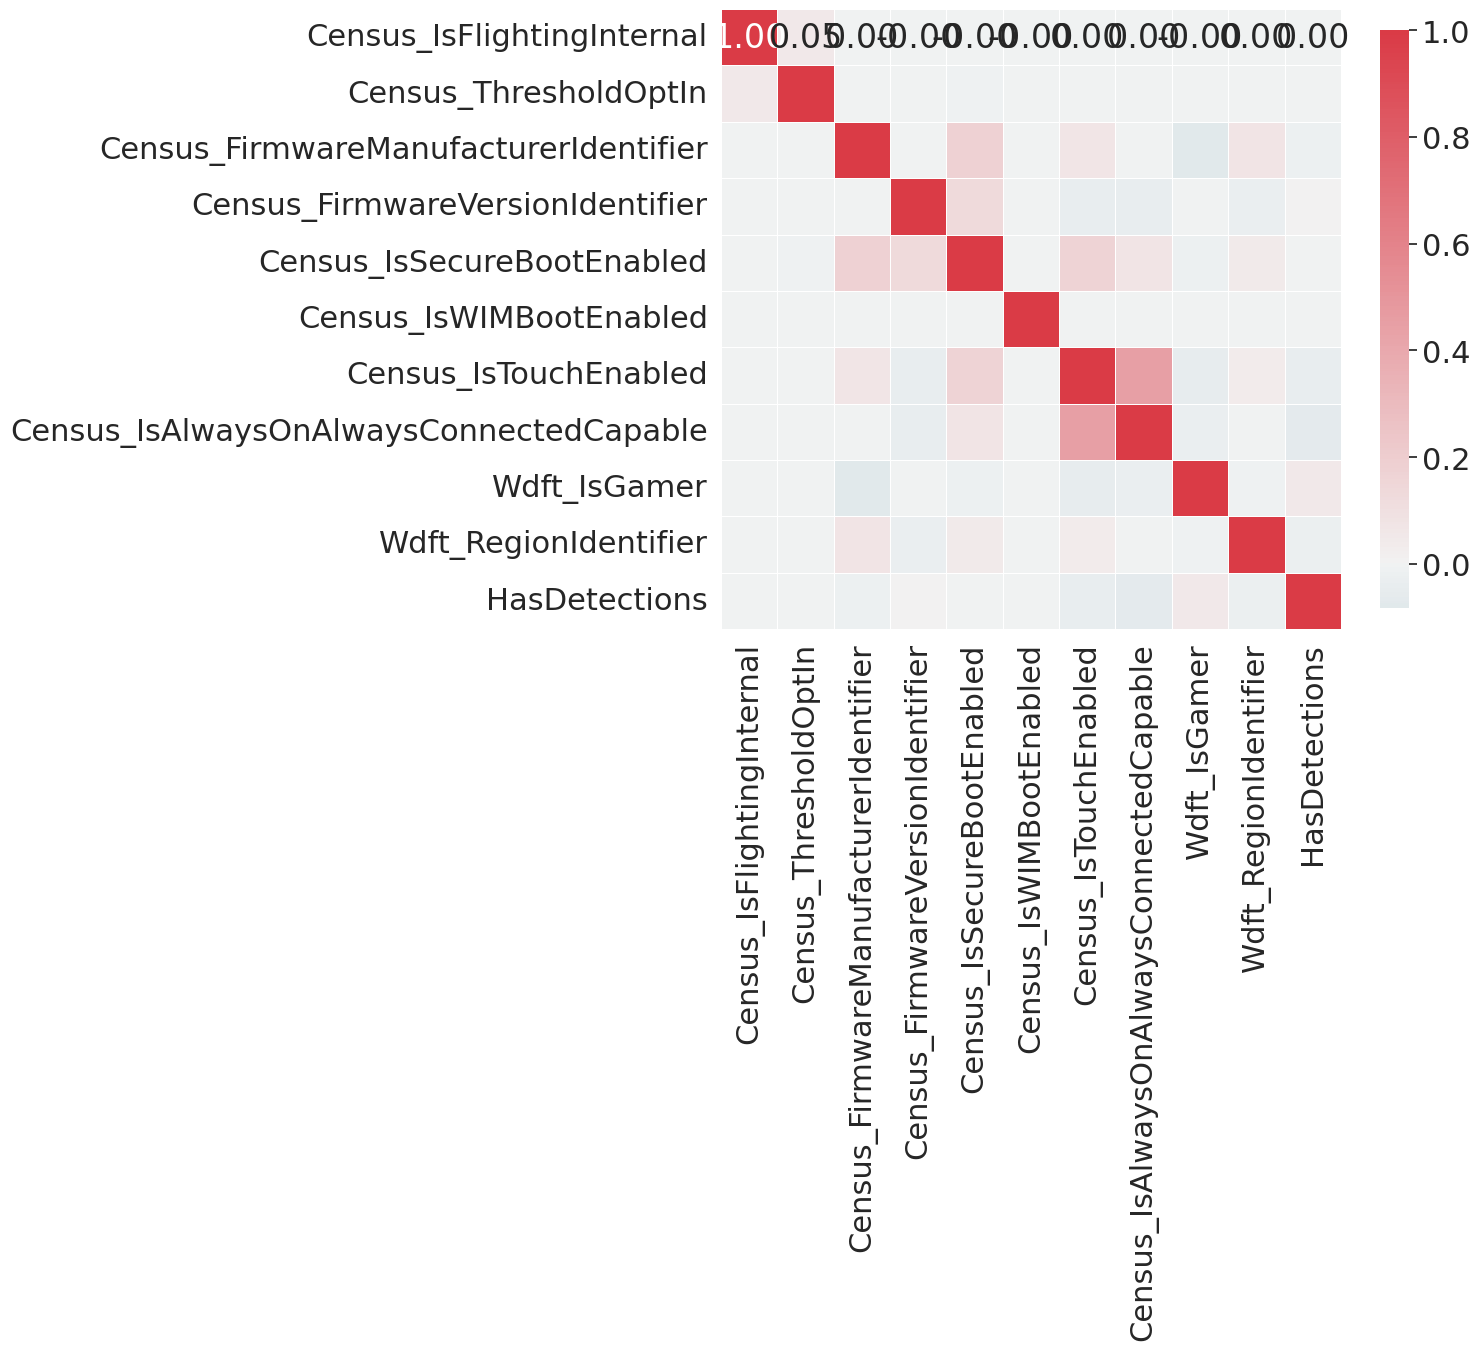

In [18]:
corr_heatmap(col[30:40])

In [24]:
#分析非NA特征关联矩阵
#分段分析，特征较多


In [70]:
#删除相关性太强的特征
X['AVProductStatesIdentifier']= X['AVProductStatesIdentifier']-X['AVProductsInstalled']
X['Census_OSBuildRevision'] = X['Census_OSBuildNumber']-X['Census_OSBuildRevision']
X.info()
X.drop(['AVProductsInstalled','Census_OSBuildRevision','GeoNameIdentifier','Census_ProcessorModelIdentifier','Census_InternalPrimaryDisplayResolutionVertical','Census_IsAlwaysOnAlwaysConnectedCapable'],axis=1,inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 16774736 entries, 0 to 7853252
Data columns (total 65 columns):
 #   Column                                             Dtype  
---  ------                                             -----  
 0   MachineIdentifier                                  object 
 1   EngineVersion                                      object 
 2   AppVersion                                         object 
 3   AvSigVersion                                       object 
 4   DefaultBrowsersIdentifier                          float64
 5   AVProductStatesIdentifier                          float64
 6   AVProductsInstalled                                float64
 7   CountryIdentifier                                  int64  
 8   CityIdentifier                                     float64
 9   OrganizationIdentifier                             float64
 10  GeoNameIdentifier                                  float64
 11  LocaleEnglishNameIdentifier                        int

In [71]:
#进行特征编码
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
# 使用 pandas 的 get_dummies 函数进行独热编码
cols=[]
for i in X.columns:
    if X[i].dtype=='object':
        cols.append(i)
print(cols)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cols:
    X[col] = le.fit_transform(X[col])
# X = pd.get_dummies(X, columns=cols,sparse=True)

['MachineIdentifier', 'EngineVersion', 'AppVersion', 'AvSigVersion', 'Processor', 'OsPlatformSubRelease', 'OsBuildLab', 'SkuEdition', 'SmartScreen', 'Census_MDC2FormFactor', 'Census_PrimaryDiskTypeName', 'Census_ChassisTypeName', 'Census_PowerPlatformRoleName', 'Census_InternalBatteryType', 'Census_OSVersion', 'Census_OSArchitecture', 'Census_OSBranch', 'Census_OSEdition', 'Census_OSSkuName', 'Census_OSInstallTypeName', 'Census_OSWUAutoUpdateOptionsName', 'Census_GenuineStateName', 'Census_ActivationChannel', 'Census_FlightRing']


In [72]:
print(X.columns)

Index(['MachineIdentifier', 'EngineVersion', 'AppVersion', 'AvSigVersion',
       'DefaultBrowsersIdentifier', 'AVProductStatesIdentifier',
       'CountryIdentifier', 'CityIdentifier', 'OrganizationIdentifier',
       'LocaleEnglishNameIdentifier', 'Processor', 'OsBuild', 'OsSuite',
       'OsPlatformSubRelease', 'OsBuildLab', 'SkuEdition', 'IsProtected',
       'SMode', 'IeVerIdentifier', 'SmartScreen', 'Census_MDC2FormFactor',
       'Census_OEMNameIdentifier', 'Census_OEMModelIdentifier',
       'Census_ProcessorCoreCount', 'Census_ProcessorManufacturerIdentifier',
       'Census_PrimaryDiskTotalCapacity', 'Census_PrimaryDiskTypeName',
       'Census_SystemVolumeTotalCapacity', 'Census_HasOpticalDiskDrive',
       'Census_TotalPhysicalRAM', 'Census_ChassisTypeName',
       'Census_InternalPrimaryDiagonalDisplaySizeInInches',
       'Census_InternalPrimaryDisplayResolutionHorizontal',
       'Census_PowerPlatformRoleName', 'Census_InternalBatteryType',
       'Census_InternalBattery

In [12]:
import matplotlib
#把X不同类型的数据都转换为分类数据
for i in X.columns:
    X[i] = X[i].astype('category')
X.info()


KeyboardInterrupt



In [53]:
#保存变量
X.to_csv('x3.csv', index=True)

In [4]:
#读取
X = pd.read_csv('./x2.csv')

In [5]:
#划分训练数据和测试数据
from sklearn.model_selection import train_test_split
X.drop(['MachineIdentifier'],axis=1,inplace=True)

KeyError: "['MachineIdentifier'] not found in axis"

In [ ]:
# fig = plt.figure(figsize=(18,20))
# for index in range(len(X.columns)):
#     plt.subplot(14,4,index+1)
#     sns.countplot(x=X.iloc[:,index], data=X)
#     plt.xticks(rotation=90)
# fig.tight_layout(pad=1.0)

In [73]:
y=X[['HasDetections']]
X.drop(['HasDetections'],axis=1,inplace=True)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
#X size一定要改

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
feature_importances = clf.feature_importances_

# 对特征重要性进行排序并获取前10个
# sorted_indices = np.argsort(feature_importances)[::-1][:10]
# 示例特征名称
# feature_names = [col for col in X.columns]
# 获取排序后的特征名称
# sorted_feature_names = [feature_names[i] for i in sorted_indices]
# 准备绘图
# plt.figure(figsize=(12, 6))
# plt.title("Top 10 Feature Importances with Feature Names")
# plt.bar(range(10), feature_importances[sorted_indices], align='center')
# plt.xticks(range(10), sorted_feature_names, rotation=45)
# plt.xlabel("Feature Names")
# plt.ylabel("Importance")
# plt.show()

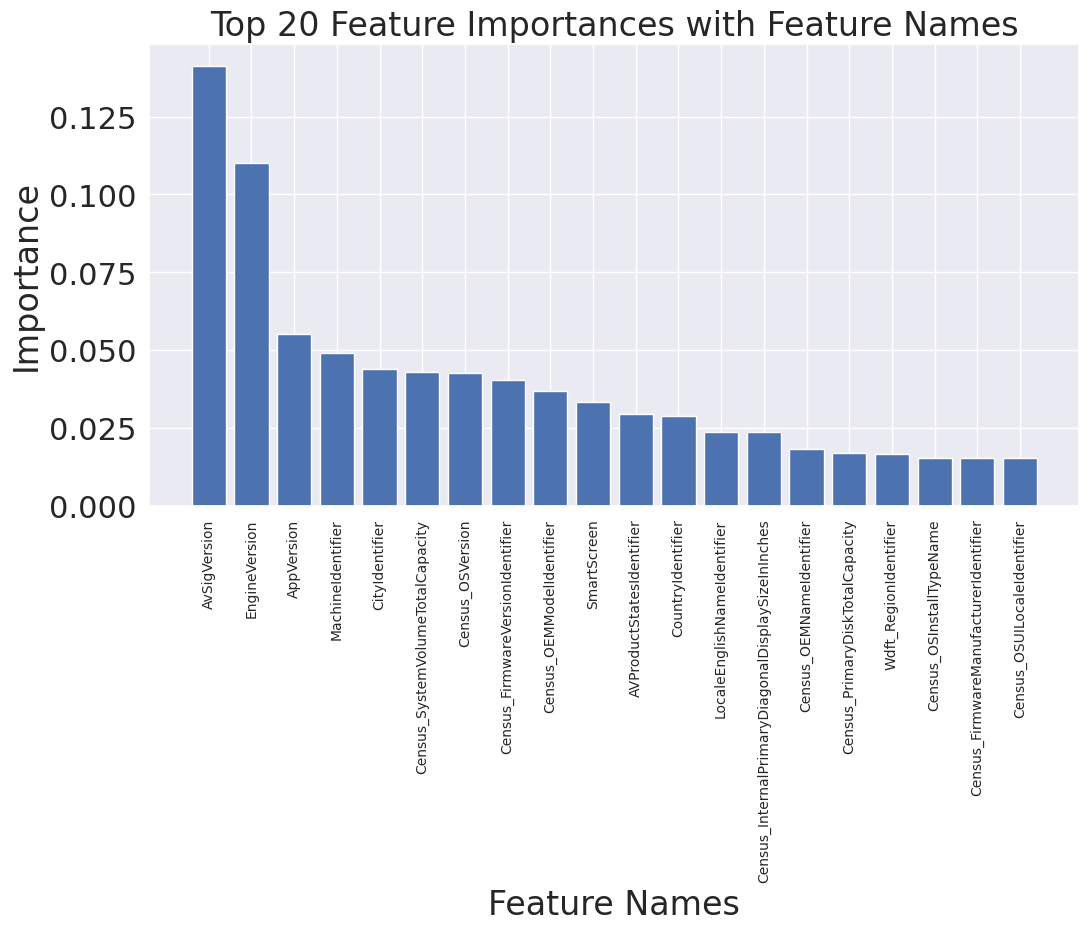

In [23]:
# 对特征重要性进行排序并获取前10个
sorted_indices = np.argsort(feature_importances)[::-1][:20]
# 示例特征名称
feature_names = [col for col in X.columns]
# 获取排序后的特征名称
sorted_feature_names = [feature_names[i] for i in sorted_indices]
# 准备绘图
plt.rcParams.update({'font.size':5}) 
plt.figure(figsize=(12, 6))
plt.title("Top 20 Feature Importances with Feature Names")
plt.bar(range(20), feature_importances[sorted_indices], align='center')
plt.xticks(range(20), sorted_feature_names, rotation=90,fontsize=10)
plt.xlabel("Feature Names")
plt.ylabel("Importance")
plt.show()

In [24]:
X = X[sorted_feature_names]

In [138]:
cols = ['AvSigVersion', 'EngineVersion', 'AppVersion',
       'CityIdentifier', 'Census_SystemVolumeTotalCapacity',
       'Census_OSVersion', 'Census_FirmwareVersionIdentifier',
       'Census_OEMModelIdentifier', 'SmartScreen', 'AVProductStatesIdentifier',
       'CountryIdentifier', 'LocaleEnglishNameIdentifier',
       'Census_InternalPrimaryDiagonalDisplaySizeInInches',
       'Census_OEMNameIdentifier', 'Census_PrimaryDiskTotalCapacity',
       'Wdft_RegionIdentifier', 'Census_OSInstallTypeName',
       'Census_FirmwareManufacturerIdentifier', 'Census_OSUILocaleIdentifier']
#MachineIdentifier
X = X[cols]

In [74]:
print(X.columns)

Index(['MachineIdentifier', 'EngineVersion', 'AppVersion', 'AvSigVersion',
       'DefaultBrowsersIdentifier', 'AVProductStatesIdentifier',
       'CountryIdentifier', 'CityIdentifier', 'OrganizationIdentifier',
       'LocaleEnglishNameIdentifier', 'Processor', 'OsBuild', 'OsSuite',
       'OsPlatformSubRelease', 'OsBuildLab', 'SkuEdition', 'IsProtected',
       'SMode', 'IeVerIdentifier', 'SmartScreen', 'Census_MDC2FormFactor',
       'Census_OEMNameIdentifier', 'Census_OEMModelIdentifier',
       'Census_ProcessorCoreCount', 'Census_ProcessorManufacturerIdentifier',
       'Census_PrimaryDiskTotalCapacity', 'Census_PrimaryDiskTypeName',
       'Census_SystemVolumeTotalCapacity', 'Census_HasOpticalDiskDrive',
       'Census_TotalPhysicalRAM', 'Census_ChassisTypeName',
       'Census_InternalPrimaryDiagonalDisplaySizeInInches',
       'Census_InternalPrimaryDisplayResolutionHorizontal',
       'Census_PowerPlatformRoleName', 'Census_InternalBatteryType',
       'Census_InternalBattery

In [75]:
X.dropna(inplace=True)

In [76]:
print(X.shape, y.shape)

(16774736, 58) (16774736, 1)


In [63]:
print(X.isnull().sum())
print(y.isnull().sum())

Unnamed: 0                                           0
EngineVersion                                        0
AppVersion                                           0
AvSigVersion                                         0
DefaultBrowsersIdentifier                            0
AVProductStatesIdentifier                            0
CountryIdentifier                                    0
CityIdentifier                                       0
OrganizationIdentifier                               0
LocaleEnglishNameIdentifier                          0
Processor                                            0
OsBuild                                              0
OsSuite                                              0
OsPlatformSubRelease                                 0
OsBuildLab                                           0
SkuEdition                                           0
IsProtected                                          0
SMode                                                0
IeVerIdent

In [10]:
X.drop(['Unnamed: 0'],axis=1,inplace=True)

In [20]:
#模型训练
# param_grid = {
#     'n_estimators': [10000, 5000, 13000],  #
#     'max_depth': [5,8,10,13],  
#     'learning_rate': [0.04,0.07,0.10,0.13],  
# }
# grid_search = GridSearchCV(lof, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
# grid_search.fit(X)
# best_params = grid_search.best_params_

lgb_model = lgb.LGBMClassifier(n_estimators=10000, colsample_bytree=0.5, objective='binary', num_leaves=2048, boosting="gbdt",
            verbose=-1, max_depth=5, learning_rate=0.07)

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc,roc_auc_score
clfs = list()
oof_preds = np.zeros(X.shape[0])
    # Split data with kfold
kfolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for n_fold, (trn_idx, val_idx) in enumerate(kfolds.split(X, y)):
    X_train, y_train = X.iloc[trn_idx], y.iloc[trn_idx]
    X_valid, y_valid = X.iloc[val_idx], y.iloc[val_idx]

    # LightGBM Regressor estimator
    
    lgb_model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric='auc',
            
        )
    y_scores = lgb_model.predict_proba(X_valid)[:, 1]
    y_true = y_valid
    fpr1, tpr1, thresholds = roc_curve(y_true, y_scores)
    auc_value1 = auc(fpr1, tpr1)
    clfs.append(lgb_model)
    oof_preds[val_idx] = lgb_model.predict(X_valid, num_iteration=lgb_model.best_iteration_)
        
    score = roc_auc_score(y, oof_preds)
    print(score)


KeyboardInterrupt



In [ ]:
# lgb_model.load_state_dict(torch.load(os.path.join(config.checkpoints_dir, 'gat_best_model.pth.tar'))['state_dict'])

y_test_preds = test(lgb_model, X_train)

# confusion matrix on validation data
conf_mat = confusion_matrix(X_train.y[data_train.val_idx].detach().cpu().numpy(), y_test_preds[valid_idx].cpu())

plt.subplots(figsize=(6,6))
sns.set(font_scale=1.4)
sns.heatmap(conf_mat, annot=True, fmt=".0f", annot_kws={"size": 16}, cbar=False)
plt.xlabel('Target (true) Class'); plt.ylabel('Output (predicted) class'); plt.title('Confusion Matrix')
plt.show();

print(classification_report(data_train.y[data_train.val_idx].detach().cpu().numpy(),
                            y_test_preds[valid_idx].cpu(),
                            target_names=['licit', 'illicit']))

In [ ]:
print(score)

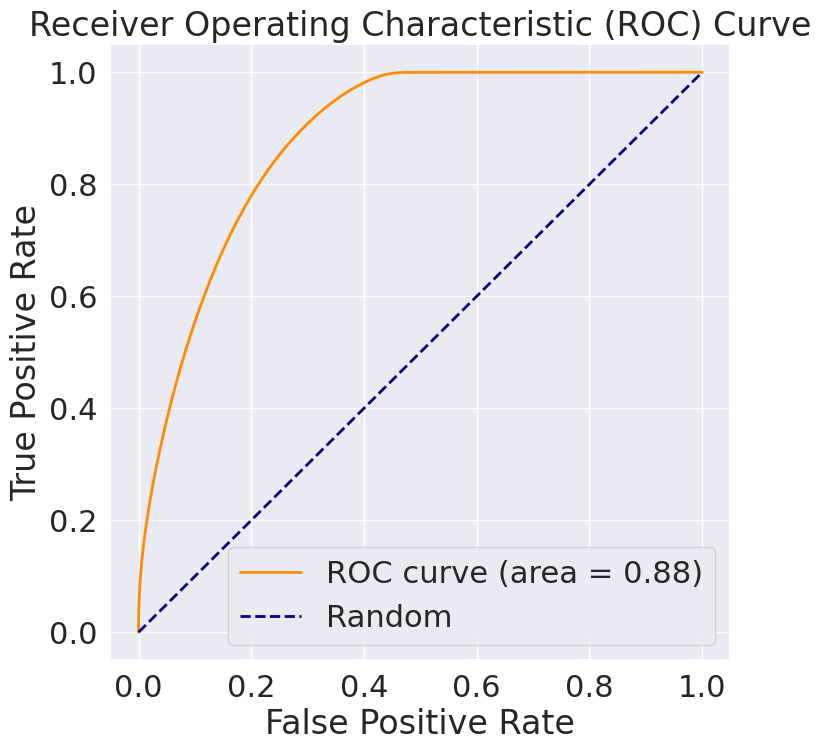

In [40]:
# 绘制ROC曲线
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(auc(fpr, tpr)))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [45]:
#xgboost参数配置
# param_grid = {
#     'early_stopping_rounds': [180, 100, 230],  #
#     'eta': [0.3,0.36,0.4,0.44],      
# }
# grid_search = GridSearchCV(lof, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
# grid_search.fit(X)
# best_params = grid_search.best_params_
xgb_model = xgb.XGBClassifier(objective='binary:logistic',
                early_stopping_rounds=180,
                eta=0.44,
                verbose=-1)


In [46]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc,roc_auc_score
clfs = list()
oof_preds = np.zeros(X.shape[0])
    # Split data with kfold
kfolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for n_fold, (trn_idx, val_idx) in enumerate(kfolds.split(X, y)):
    X_train, y_train = X.iloc[trn_idx], y.iloc[trn_idx]
    X_valid, y_valid = X.iloc[val_idx], y.iloc[val_idx]

    # xgboost模型
    xgb_model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric='auc',
            
        )
    y_scores = xgb_model.predict_proba(X_valid)[:, 1]
    y_true = y_valid
    fpr2, tpr2, thresholds = roc_curve(y_true, y_scores)
    auc_value2 = auc(fpr2, tpr2)
    clfs.append(xgb_model)
    oof_preds[val_idx] = xgb_model.predict(X_valid, iteration_range=(0, xgb_model.best_iteration))
        
    score = roc_auc_score(y, oof_preds)
    print(score)

[0]	validation_0-auc:0.67246
[1]	validation_0-auc:0.68923
[2]	validation_0-auc:0.69511
[3]	validation_0-auc:0.69769
[4]	validation_0-auc:0.70029
[5]	validation_0-auc:0.70215
[6]	validation_0-auc:0.70431
[7]	validation_0-auc:0.70607
[8]	validation_0-auc:0.70733
[9]	validation_0-auc:0.70851
[10]	validation_0-auc:0.70932
[11]	validation_0-auc:0.71058
[12]	validation_0-auc:0.71284
[13]	validation_0-auc:0.71345
[14]	validation_0-auc:0.71434
[15]	validation_0-auc:0.71481
[16]	validation_0-auc:0.71531
[17]	validation_0-auc:0.71580
[18]	validation_0-auc:0.71633
[19]	validation_0-auc:0.71663
[20]	validation_0-auc:0.71747
[21]	validation_0-auc:0.71828
[22]	validation_0-auc:0.71841
[23]	validation_0-auc:0.71864
[24]	validation_0-auc:0.71929
[25]	validation_0-auc:0.71961
[26]	validation_0-auc:0.71987
[27]	validation_0-auc:0.72006
[28]	validation_0-auc:0.72029
[29]	validation_0-auc:0.72041
[30]	validation_0-auc:0.72071
[31]	validation_0-auc:0.72136
[32]	validation_0-auc:0.72152
[33]	validation_0-au

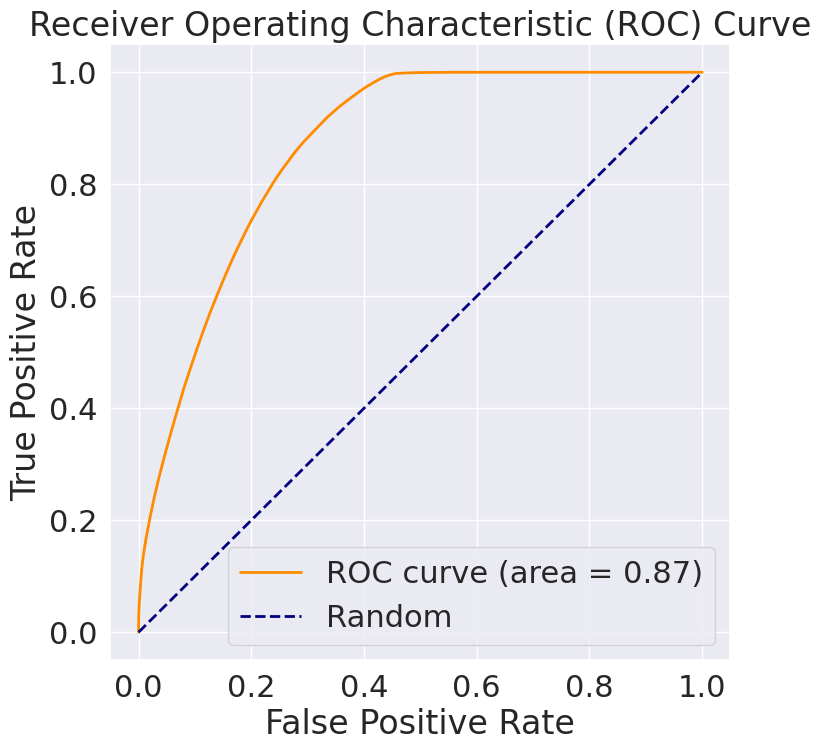

In [39]:
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(auc(fpr, tpr)))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [47]:
from sklearn.ensemble import RandomForestClassifier
#随机森林分类器
rdf_model = RandomForestClassifier(max_depth=10,
                                   verbose=True, 
                                   min_samples_leaf=100,
                                   n_estimators=100,
                                   n_jobs=-1,
                                   random_state=42)

In [48]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc,roc_auc_score
clfs = list()
oof_preds = np.zeros(X.shape[0])
    # Split data with kfold
kfolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for n_fold, (trn_idx, val_idx) in enumerate(kfolds.split(X, y)):
    X_train, y_train = X.iloc[trn_idx], y.iloc[trn_idx]
    X_valid, y_valid = X.iloc[val_idx], y.iloc[val_idx]

    # 随机森林
    rdf_model.fit(X_train, y_train)
    y_scores = rdf_model.predict_proba(X_valid)[:, 1]
    y_true = y_valid
    fpr3, tpr3, thresholds = roc_curve(y_true, y_scores)
    auc_value3 = auc(fpr3, tpr3)
    clfs.append(rdf_model)
    oof_preds[val_idx] = rdf_model.predict(X_valid)
        
    score = roc_auc_score(y, oof_preds)
    print(score)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   27.6s finished
[Parallel(n_jobs=40)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 100 out of 100 | elapsed:    1.4s finished
[Parallel(n_jobs=40)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 100 out of 100 | elapsed:    1.3s finished


0.5286745610997218


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   28.3s finished
[Parallel(n_jobs=40)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 100 out of 100 | elapsed:    1.4s finished
[Parallel(n_jobs=40)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 100 out of 100 | elapsed:    1.2s finished


0.5573730156173667


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   28.5s finished
[Parallel(n_jobs=40)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 100 out of 100 | elapsed:    1.0s finished
[Parallel(n_jobs=40)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 100 out of 100 | elapsed:    0.9s finished


0.5862833533821833


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   29.7s finished
[Parallel(n_jobs=40)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 100 out of 100 | elapsed:    0.9s finished
[Parallel(n_jobs=40)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 100 out of 100 | elapsed:    0.9s finished


0.6151412016489564


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   29.5s finished
[Parallel(n_jobs=40)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 100 out of 100 | elapsed:    0.9s finished
[Parallel(n_jobs=40)]: Using backend ThreadingBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done 100 out of 100 | elapsed:    0.9s finished


0.6438381644941427


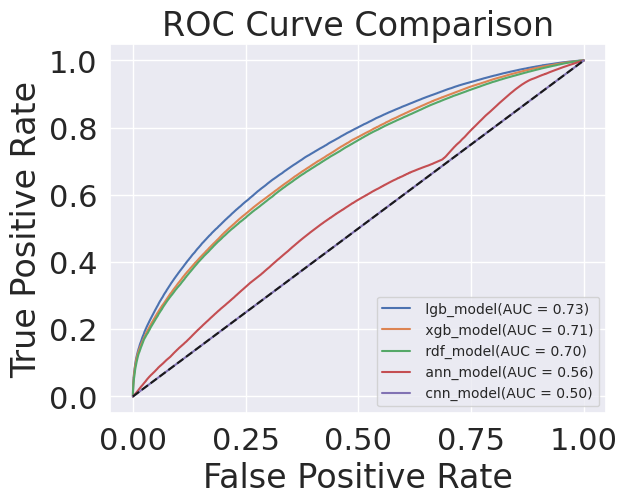

In [126]:
plt.plot(fpr1, tpr1, label=f' lgb_model(AUC = {auc_value1:.2f})')
plt.plot(fpr2, tpr2, label=f' xgb_model(AUC = {auc_value2:.2f})')
plt.plot(fpr3, tpr3, label=f' rdf_model(AUC = {auc_value3:.2f})')
plt.plot(fpr4, tpr4, label=f' ann_model(AUC = {auc4:.2f})')
plt.plot(fpr5, tpr5, label=f' cnn_model(AUC = {auc5:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # 绘制对角线
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right', prop={'size': 10})
plt.show()


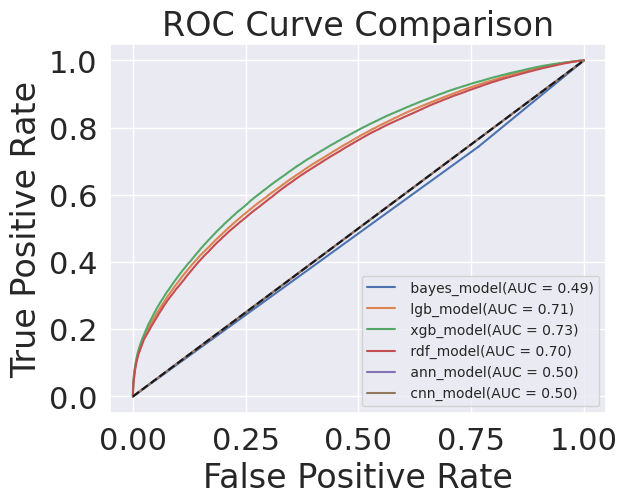

In [61]:
plt.plot(fpr6, tpr6, label=f' bayes_model(AUC = {auc_value6:.2f})')
plt.plot(fpr1, tpr1, label=f' lgb_model(AUC = {auc_value1:.2f})')
plt.plot(fpr2, tpr2, label=f' xgb_model(AUC = {auc_value2:.2f})')
plt.plot(fpr3, tpr3, label=f' rdf_model(AUC = {auc_value3:.2f})')
plt.plot(fpr5, tpr5, label=f' ann_model(AUC = {auc5:.2f})')
plt.plot(fpr5, tpr5, label=f' cnn_model(AUC = {auc5:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # 绘制对角线
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right', prop={'size': 10})
plt.show()

In [56]:
print(auc4)
print(auc5)

0.5694188944059229
0.5000966678048607


In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc,roc_auc_score
import keras
from keras import callbacks

2023-12-29 09:52:49.622702: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-12-29 09:52:50.067462: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-29 09:52:51.334207: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-12-29 09:52:51.334440: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-12-29 09:52:51.535314: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [12]:
#评估函数
class printAUC(callbacks.Callback):
    def __init__(self, X_train, y_train):
        super(printAUC, self).__init__()
        self.bestAUC = 0
        self.X_train = X_train
        self.y_train = y_train
        self.y_val = y_val
        self.X_val = X_val
        
    def on_epoch_end(self, epoch, logs={}):
        pred = self.model.predict(np.array(self.X_train))
        auc = roc_auc_score(self.y_train, pred)
        print("Train AUC: " + str(auc))
        pred = self.model.predict(self.X_val)
        fpr4, tpr4, thresholds = roc_curve(self.y_val,pred)
        auc4 = roc_auc_score(self.y_val, pred)
        print ("Validation AUC: " + str(auc))
        if (self.bestAUC < auc) :
            self.bestAUC = auc
            # self.model.save("bestNet.h5", overwrite=True)
        return fpr4,tpr4,auc4

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from keras.layers import Dense, Dropout, BatchNormalization, Activation
from keras.optimizers import Adam

# 构建ANN模型
ann_model = models.Sequential()

# 添加输入层和隐藏层
ann_model.add(Dense(100,kernel_initializer='he_uniform',input_dim=len(X.columns)))
ann_model.add(Dropout(0.2))
ann_model.add(BatchNormalization())
ann_model.add(Activation('elu'))
ann_model.add(Dense(100,kernel_initializer='he_uniform'))
ann_model.add(Dropout(0.2))
ann_model.add(BatchNormalization())
ann_model.add(Activation('elu'))
ann_model.add(Dense(100,kernel_initializer='he_uniform'))
ann_model.add(Dropout(0.2))
ann_model.add(BatchNormalization())
ann_model.add(Activation('elu'))
ann_model.add(Dense(100,kernel_initializer='he_uniform'))
ann_model.add(Dropout(0.2))
ann_model.add(BatchNormalization())
ann_model.add(Activation('elu'))
ann_model.add(Dense(1, activation='sigmoid'))
ann_model.compile(optimizer=Adam(learning_rate=0.01), loss="binary_crossentropy", metrics=["accuracy"])
# ann_model.add(layers.Dense(128, activation='relu', input_shape=(58,)))
# ann_model.add(layers.Dense(64, activation='relu',input_shape=(58,)))
# ann_model.add(layers.Dense(64, activation='relu',input_shape=(58,)))
# ann_model.add(layers.Dense(64, activation='relu',input_shape=(58,)))
# ann_model.add(layers.Dense(64, activation='relu',input_shape=(58,)))
# ann_model.add(layers.Dense(64, activation='relu',input_shape=(58,)))
# ann_model.add(layers.Dense(64, activation='relu',input_shape=(58,)))

# 使用sigmoid激活函数进行二分类
# ann_model.add(layers.Dense(1, activation='sigmoid',input_shape=(58,)))
# ann_model.compile(optimizer='adam',
#               loss='binary_crossentropy',
#               metrics=['accuracy'])



2023-12-29 09:52:56.892068: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [14]:
#ann训练不使用k折交叉验证y
from sklearn.model_selection import train_test_split
from keras.callbacks import LearningRateScheduler
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.5)
#动态调整学习率
annealer = LearningRateScheduler(lambda x: 1e-2 * 0.95 ** x)
ann_model.fit(X_train,y_train, batch_size=32, epochs = 20, callbacks=[annealer,printAUC(X_train, y_train)], validation_data = (X_val,y_val), verbose=2)
# pred = self.model.predict(self.X_val)
# fpr4, tpr4, thresholds = roc_curve(y_val,pred)
# auc4 = roc_auc_score(y_val, pred)


Epoch 1/20
22069/22069 [==============================] - 49s 2ms/step
Train AUC: 0.5429961421835332
22069/22069 [==============================] - 47s 2ms/step
Validation AUC: 0.5429961421835332
22069/22069 - 283s - loss: 0.6949 - accuracy: 0.5045 - val_loss: 0.6939 - val_accuracy: 0.4928 - lr: 0.0100 - 283s/epoch - 13ms/step
Epoch 2/20
22069/22069 [==============================] - 47s 2ms/step
Train AUC: 0.5407440142966413
22069/22069 [==============================] - 43s 2ms/step
Validation AUC: 0.5407440142966413
22069/22069 - 271s - loss: 0.6944 - accuracy: 0.5044 - val_loss: 0.6927 - val_accuracy: 0.5166 - lr: 0.0095 - 271s/epoch - 12ms/step
Epoch 3/20
22069/22069 [==============================] - 34s 2ms/step
Train AUC: 0.54152499859686
22069/22069 [==============================] - 32s 1ms/step
Validation AUC: 0.54152499859686
22069/22069 - 245s - loss: 0.6941 - accuracy: 0.5078 - val_loss: 0.6938 - val_accuracy: 0.5261 - lr: 0.0090 - 245s/epoch - 11ms/step
Epoch 4/20
22069/

In [21]:
pred = ann_model.predict(X_val)
fpr4, tpr4, thresholds = roc_curve(y_val,pred)
auc4 = roc_auc_score(y_val, pred)

22069/22069 [==============================] - 51s 2ms/step


In [127]:
from keras.models import load_model
cnn_model = load_model('CNN_model_4.h5')

In [130]:
#混淆矩阵评定
from sklearn.model_selection import train_test_split
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# X_test_padded = np.pad(X_test, (0, 2), 'constant')

# # 重塑数组
# reshaped_X_test = X_test_padded.reshape(-1, 4, 5, 1)
# reshaped_X_test=X_test[:, :291880380].reshape(-1,4,5,1)np.array(X_test[:291880380]).reshape(-1,4,5,1)
# y_pred_probs = cnn_model.predict(reshaped_X_test)
# y_pred = np.where(y_pred_probs > 0.5, 1, 0) 

In [131]:
y_pred_probs = cnn_model.predict(X_test)
y_pred = np.where(y_pred_probs > 0.3, 1, 0) 

157264/157264 [==============================] - 134s 850us/step


In [142]:
from sklearn.metrics import confusion_matrix
# y_pred = y_pred[:len(y_test)]
y_pred = np.where(y_pred_probs > 0.5, 1, 0) 
conf_matrix = confusion_matrix(y_test, y_pred)

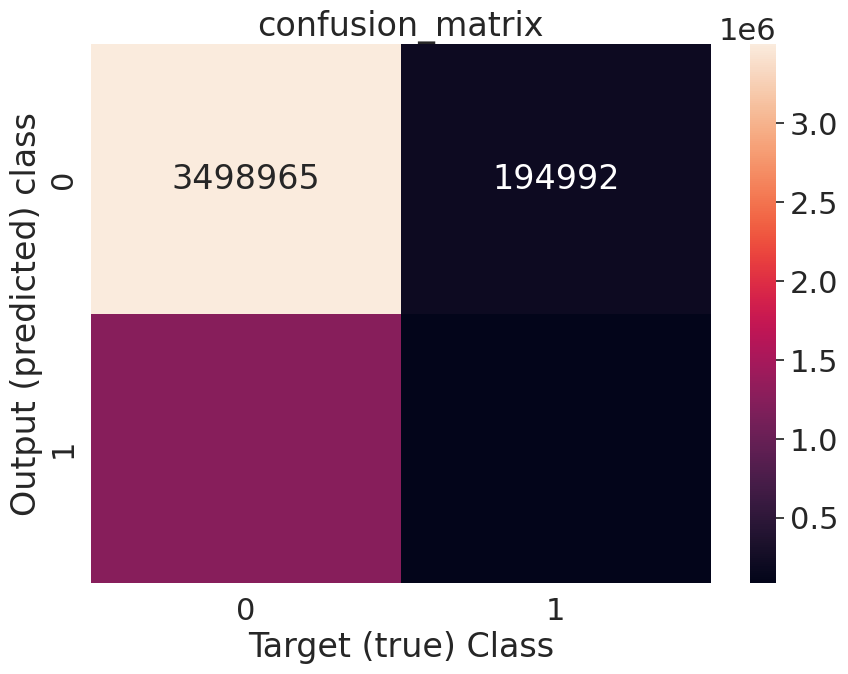

In [143]:
# 绘制混淆矩阵
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d")
plt.title('confusion_matrix')
plt.ylabel('Output (predicted) class')
plt.xlabel('Target (true) Class')
plt.show()

In [144]:
from sklearn.metrics import classification_report
final_report = classification_report(y_test, y_pred)
print(final_report)

              precision    recall  f1-score   support

         0.0       0.74      0.95      0.83   3693957
         1.0       0.31      0.06      0.11   1338464

    accuracy                           0.71   5032421
   macro avg       0.52      0.51      0.47   5032421
weighted avg       0.62      0.71      0.64   5032421



### plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(auc(fpr, tpr)))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [96]:
# # 构建CNN模型
def create_model():
    model = keras.Sequential()
#     model.add(keras.layers.Dense(100, activation='relu', input_dim=len(X.columns))) #len(pre_train_data.colums)
#     model = models.Sequential()
    model.add(keras.layers.Conv2D(32, (2, 2), activation='elu', input_shape=(2,3,1)))  
    model.add(keras.layers.MaxPooling2D((1, 2)))
#     model.add(keras.layers.Conv2D(64, (2, 2), activation='relu'))
#     model.add(keras.layers.MaxPooling2D((2, 2)))
#     model.add(keras.layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(64, activation='elu'))
    model.add(keras.layers.Dense(64, activation='elu'))
    model.add(keras.layers.Dense(64, activation='elu'))
    model.add(keras.layers.Dense(64, activation='elu'))
    model.add(keras.layers.Dense(64, activation='elu'))
    model.add(keras.layers.Dense(1, activation='sigmoid')) 
   
#     model.add(keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics='accuracy')
    return model

In [98]:
from sklearn.model_selection import train_test_split
import keras
import numpy as np

# Check the shape of X and y before splitting
print("Before split:", X.shape, y.shape)

# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5)
print("After split - Train:", X_train.shape, y_train.shape)

X_val = X_val[:-1]
y_val = y_val[:-1]
print("After split - Validation:", X_val .shape, y_val.shape)
# Ensure data integrity after split
# X_train = X_train[:706200]
assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]

# Create model
cnn_model = create_model()

# Convert to numpy arrays if they are not already
X_train = np.array(X_train)
X_valid = np.array(X_val)

# Adjusting the validation set
X_train = X_train[:len(X_valid)]
# Reshaping
reshaped_X_train = X_train.reshape(-1, 2, 3, 1)
reshaped_X_valid = X_valid.reshape(-1, 2, 3, 1)
# reshaped_X_train = reshaped_X_train[:706200]
# reshaped_X_valid = reshaped_X_valid[:706200]
# Check shapes after reshapingreshaped_X_train = 
print("After reshape:", reshaped_X_train.shape, reshaped_X_valid.shape, y_train.shape, y_val.shape)

# Ensure data integrity after reshape
assert reshaped_X_train.shape[0] == y_train.shape[0]
assert reshaped_X_valid.shape[0] == y_val.shape[0]

# Fit the model
history = cnn_model.fit(reshaped_X_train, y_train, epochs=20, 
                        validation_data=(reshaped_X_valid, y_val), 
                       )

# Save the model
cnn_model.save(f"./CNN_model_{5+1}.h5")


Before split: (16774736, 58) (16774736, 1)
After split - Train: (8387368, 58) (8387368, 1)
After split - Validation: (8387367, 58) (8387367, 1)
After reshape: (81077881, 2, 3, 1) (81077881, 2, 3, 1) (282480, 1) (8387367, 1)


AssertionError: 

In [ ]:
clfs = list()
oof_preds = np.zeros(X.shape[0])

print(X_train.shape,X_val.shape)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.5)
print(y_train.shape,y_val.shape)
      
cnn_model = create_model()
X_train = X_train.values
X_valid = X_val.values
X_valid = X_valid[:-1]
y_val = y_val[:-1]
reshaped_X_train = X_train.reshape(-1, 4, 5, 1) 
reshaped_X_valid = X_valid.reshape(-1, 4, 5, 1)
print(X_train.shape,X_valid.shape,y_train.shape,y_val.shape)
history=cnn_model.fit(reshaped_X_train,y_train, epochs=20, validation_data=(reshaped_X_valid, y_val))  
cnn_model.save(f"./CNN_model_{n_fold+1}.h5")
    
 #损失函数图形
# plt.plot(history.history['loss']) 
# plt.plot(history.history['val_loss'])
# plt.xlabel('epoch') 
# plt.ylabel('loss') 
# plt.legend(['train', 'val']) 
# plt.show()
    
    # cnn_model.fit(
    #     X_train_padded, y_train, 
    #     epochs=5, 
    #     validation_data=(X_valid_padded , y_valid)   
    #     )
    # y_scores = ann_model.predict(X_valid)
    # y_true = y_valid
    # fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    # auc_value = auc(fpr, tpr)
    # clfs.append(ann_model)
oof_preds[val_idx] = cnn_model.predict(X_valid).reshape(-1)     
score = roc_auc_score(y, oof_preds)
print(score)

In [53]:
pred = cnn_model.predict(reshaped_X_valid)
fpr5, tpr5, thresholds = roc_curve(y_val,pred)
auc5 = roc_auc_score(y_val, pred)

22069/22069 [==============================] - 38s 2ms/step


In [36]:
#朴素贝叶斯模型
#把数据集负值取反
X = np.abs(X)
y = np.abs(y)

In [37]:
from sklearn.naive_bayes import MultinomialNB
bayes_model = MultinomialNB()

In [40]:
clfs = list()
oof_preds = np.zeros(X.shape[0])
    # Split data with kfold
kfolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for n_fold, (trn_idx, val_idx) in enumerate(kfolds.split(X, y)):
    X_train, y_train = X.iloc[trn_idx], y.iloc[trn_idx]
    X_valid, y_valid = X.iloc[val_idx], y.iloc[val_idx]

    # 朴素贝叶斯
    bayes_model.fit(X_train, y_train)
    y_scores = bayes_model.predict_proba(X_valid)[:, 1]
    y_true = y_valid
    fpr6, tpr6, thresholds = roc_curve(y_true, y_scores)
    auc_value6 = auc(fpr6, tpr6)
    clfs.append(bayes_model)
    oof_preds[val_idx] = bayes_model.predict(X_valid)
        
    score = roc_auc_score(y, oof_preds)
    # score = accuracy_score(y, oof_preds)
    print(score)

0.4974173725020565
0.4998312716761118
0.4980191878879098
0.4956789814481155
0.4933857814332999


In [ ]:
#组合特征与预测变量的关联程度，可以用模型搜索？

In [26]:
X.shape

(16774736, 64)

In [28]:
#有些特征要么是零要么是一，要重新归类，而且这块得放在前面，否则后面数据处理都有问题